# Progress Measures for Grokking via Mechanistic Interpretability

An accompanying notebook for [Progress Measures for Grokking via Mechanistic Interpretability](https://www.progress-measures-grokking.io/) for reproducibility. This notebook contains the code used to generate most of our main figures, the progress measures and code to access the saved model weights from our mainline analysis.

# Setup
A collection of helper functions and setup code, no need to read. Modular addition model training code included for reference

In [ ]:
from IPython import get_ipython
ipython = get_ipython()
try:
  import google.colab
  IN_COLAB = True
  print("Running as a Colab notebook")
  ipython.magic("pip install einops")
  ipython.magic("pip install -U kaleido")
  ipython.magic("pip install -U plotly")

except:
  IN_COLAB = False
  print("Running as a Jupyter notebook - intended for development only!")

  # Code to automatically update imports as code is edited without restarting the kernel
  ipython.magic("load_ext autoreload")
  ipython.magic("autoreload 2")
  %config Completer.use_jedi = False


Running as a Colab notebook
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 86.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
import tqdm.notebook as tqdm

import random
import time

# from google.colab import drive
from pathlib import Path
import pickle
import os

import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import plotly.io as pio
if IN_COLAB:
    pio.renderers.default = "colab"
else:
    pio.renderers.default = "vscode"

import plotly.graph_objects as go

# Set Plotly renderer for the current environment
if IN_COLAB:
    pio.renderers.default = 'colab'
else:
    pio.renderers.default = 'notebook'  # works in VS Code / JupyterLab

from torch.utils.data import DataLoader

from functools import *
import pandas as pd
import gc

# import comet_ml
import itertools


In [ ]:
# ─────────────────────────────────────────────────────────
# Plotting utilities (inlined from plot.py — no local file needed)
# ─────────────────────────────────────────────────────────
import copy, re

def to_numpy(tensor, flat=False):
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, list):
        return np.array(tensor)
    elif isinstance(tensor, torch.Tensor):
        if flat:
            return tensor.flatten().detach().cpu().numpy()
        else:
            return tensor.detach().cpu().numpy()
    elif type(tensor) in [int, float, bool, str]:
        return np.array(tensor)
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")


def melt(tensor):
    arr = to_numpy(tensor)
    n = arr.ndim
    grid = np.ogrid[tuple(map(slice, arr.shape))]
    out = np.empty(arr.shape + (n+1,), dtype=np.result_type(arr.dtype, int))
    offset = 1
    for i in range(n):
        out[..., i+offset] = grid[i]
    out[..., -1+offset] = arr
    out.shape = (-1, n+1)
    df = pd.DataFrame(out, columns=['value']+[str(i) for i in range(n)], dtype=float)
    return df.convert_dtypes([float]+[int]*n)


def broadcast_up(array, shape, axis_str=None):
    n = len(shape)
    m = len(array.shape)
    if axis_str is None:
        axis_str = " ".join([f"x{i}" for i in range(n-m, n)])
    return einops.repeat(
        array,
        f"{axis_str}->({' '.join([f'x{i}' for i in range(n)])})",
        **{f"x{i}": shape[i] for i in range(n)},
    )


# ── Kwargs system ──
DEFAULT_KWARGS = dict(
    xaxis="x", yaxis="y", range_x=None, range_y=None,
    animation_name="snapshot", color_name="Color", color=None,
    log_x=False, log_y=False, toggle_x=False, toggle_y=False,
    legend=True, hover=None, hover_name="data", return_fig=True,
    animation_index=None, line_labels=None, markers=False,
    frame_rate=None, facet_labels=None, debug=False, transition="none",
)

def split_kwargs(kwargs):
    custom = dict(DEFAULT_KWARGS)
    plotly = {}
    for k, v in kwargs.items(): # if kwargs input item exists within DEFAULT_KWARGS, plug into custom as a kwarg, if not, plug into plotly as a plotly arg
        if k in custom:
            custom[k] = v
        else:
            plotly[k] = v
    return custom, plotly


# ── Figure editing helpers ──
def update_play_button(button, custom_kwargs):
    button.args[1]['transition']['easing'] = custom_kwargs['transition']
    if custom_kwargs['frame_rate'] is not None:
        button.args[1]['transition']['duration'] = custom_kwargs['frame_rate']
        button.args[1]['frame']['duration'] = custom_kwargs['frame_rate']

def update_hovertemplate(data, string):
    if data.hovertemplate is not None:
        data.hovertemplate = data.hovertemplate[:-15]+"<br>"+string+"<extra></extra>"

def add_button(layout, button, pos=None):
    if pos is None:
        num_prev_buttons = len(layout.updatemenus)
        button['y'] = 1 - num_prev_buttons * 0.15
    else:
        button['y'] = pos
    if 'x' not in button:
        button['x'] = -0.1
    layout.updatemenus = layout.updatemenus + (button,)

def add_axis_toggle(layout, axis, pos=None):
    assert axis in "xy", f"Invalid axis: {axis}"
    is_already_log = layout[f"{axis}axis"].type == 'log'
    toggle_axis = dict(
        type="buttons",
        active=0 if is_already_log else -1,
        buttons=[dict(
            label=f"Log {axis}-axis",
            method="relayout",
            args=[{f"{axis}axis.type": "log"}],
            args2=[{f"{axis}axis.type": "linear"}],
        )]
    )
    add_button(layout, toggle_axis, pos=pos)


def update_data(data, custom_kwargs, index):
    if custom_kwargs['hover'] is not None and isinstance(data, go.Heatmap):
        hover = to_numpy(custom_kwargs['hover'])
        data.customdata = hover
        update_hovertemplate(data, f"{custom_kwargs['hover_name']}=%{{customdata}}")
    if custom_kwargs['markers']:
        data['mode'] = 'lines+markers'
    if custom_kwargs['line_labels'] is not None:
        data['name'] = custom_kwargs['line_labels'][index]
        data['hovertemplate'] = re.sub(
            f"={index}", f"={data['name']}", data['hovertemplate'])

def update_data_list(data_list, custom_kwargs):
    for c, data in enumerate(data_list):
        update_data(data, custom_kwargs, c)

def update_frame(frame, custom_kwargs, frame_index):
    update_data_list(frame['data'], custom_kwargs)

def update_layout(layout, custom_kwargs, is_animation):
    if custom_kwargs['debug']:
        print(layout, is_animation)
    layout.xaxis.title.text = custom_kwargs['xaxis']
    layout.yaxis.title.text = custom_kwargs['yaxis']
    if custom_kwargs['range_x'] is not None:
        layout.xaxis.range = custom_kwargs['range_x']
    if custom_kwargs['range_y'] is not None:
        layout.yaxis.range = custom_kwargs['range_y']
    if custom_kwargs['log_x']:
        layout.xaxis.type = 'log'
    if custom_kwargs['log_y']:
        layout.yaxis.type = 'log'
    if custom_kwargs['toggle_x']:
        add_axis_toggle(layout, 'x')
    if custom_kwargs['toggle_y']:
        add_axis_toggle(layout, 'y')
    if not custom_kwargs['legend']:
        layout.showlegend = False
    if custom_kwargs['facet_labels']:
        for i, label in enumerate(custom_kwargs['facet_labels']):
            layout.annotations[i]['text'] = label
            if i > 0:
                layout[f"xaxis{i+1}"].title = layout["xaxis"].title
    if is_animation:
        for updatemenu in layout.updatemenus:
            if "buttons" in updatemenu:
                for button in updatemenu['buttons']:
                    if button.label == "&#9654;":
                        update_play_button(button, custom_kwargs)
            if button.label == "&#9654;":
                button.transition.easing = custom_kwargs['transition']
                button.transition.easing = custom_kwargs['transition']
        layout.sliders[0].currentvalue.prefix = custom_kwargs['animation_name']+"="
        if custom_kwargs['animation_index'] is not None:
            steps = layout.sliders[0].steps
            for c, step in enumerate(steps):
                step.label = custom_kwargs['animation_index'][c]


def update_fig(fig, custom_kwargs, inplace=True):
    if custom_kwargs['debug']:
        print(fig.frames == tuple())
    if not inplace:
        fig = copy.deepcopy(fig)
    update_data_list(fig['data'], custom_kwargs)
    is_animation = 'frames' in fig and fig.frames != tuple()
    if is_animation:
        for frame_index, frame in enumerate(fig['frames']):
            update_frame(frame, custom_kwargs, frame_index)
    update_layout(fig.layout, custom_kwargs, is_animation)
    return fig


# ── Main plotting functions ──
def line_or_scatter(tensor, plot_type, x=None, mode='multi', squeeze=True, **kwargs):
    custom_kwargs, plotly_kwargs = split_kwargs(kwargs)
    array = to_numpy(tensor)
    animation_name = custom_kwargs['animation_name']
    xaxis = custom_kwargs['xaxis']
    yaxis = custom_kwargs['yaxis']
    color_name = custom_kwargs['color_name']
    color = custom_kwargs['color']
    if squeeze:
        array = array.squeeze()
    if animation_name:
        mode = "animate"
    df = melt(array)
    if plot_type == 'line':
        if len(df.columns) == 2:
            _x_name, _color_name, _animation_name = '0', None, None
        elif len(df.columns) == 3:
            _x_name = '1'
            if mode == 'multi':
                _color_name, _animation_name = '0', None
            elif mode == 'animate':
                _color_name, _animation_name = None, '0'
        elif len(df.columns) == 4:
            _x_name, _color_name, _animation_name = '2', '1', '0'
        else:
            raise ValueError(f"Input tensor has too many dimensions: {array.shape}")
    else:
        if len(df.columns) == 2:
            _x_name, _color_name, _animation_name = '0', None, None
        elif len(df.columns) == 3:
            _x_name, _color_name, _animation_name = '1', None, '0'
        else:
            raise ValueError(f"Input tensor has too many dimensions: {array.shape}")
        if color is not None:
            _color_name = color_name
            color = broadcast_up(to_numpy(color), array.shape)
            df[_color_name] = color.flatten()
    if x is not None:
        x = broadcast_up(to_numpy(x), array.shape)
        df[_x_name] = x.flatten()
    if custom_kwargs['hover'] is not None:
        hover_data = to_numpy(custom_kwargs['hover'])
        df[custom_kwargs['hover_name']] = broadcast_up(hover_data, array.shape)
        hover_names = [custom_kwargs['hover_name']]
    else:
        hover_names = []
    plot_fn = px.line if plot_type == 'line' else px.scatter
    fig = plot_fn(
        df, x=_x_name, y='value', color=_color_name,
        animation_frame=_animation_name, hover_data=hover_names,
        labels={_x_name: xaxis, 'value': yaxis,
                _color_name: color_name, _animation_name: animation_name},
        **plotly_kwargs)
    update_fig(fig, custom_kwargs)
    if custom_kwargs['return_fig']:
        return fig
    else:
        fig.show()

scatter = partial(line_or_scatter, plot_type='scatter')
line = partial(line_or_scatter, plot_type='line')


def imshow_base(array, **kwargs):
    custom_kwargs, plotly_kwargs = split_kwargs(kwargs)
    fig = px.imshow(array, **plotly_kwargs)
    update_fig(fig, custom_kwargs)
    if custom_kwargs['return_fig']:
        return fig
    else:
        fig.show()


def histogram(array, **kwargs):
    custom_kwargs, plotly_kwargs = split_kwargs(kwargs)
    array = to_numpy(array)
    df = melt(array)
    fig = px.histogram(df, x='value', **plotly_kwargs)
    update_fig(fig, custom_kwargs)
    if custom_kwargs['return_fig']:
        return fig
    else:
        fig.show()


legend_in_plot_dict = dict(
    xanchor='right', x=0.95, title='', orientation='h',
    y=1., yanchor='top', bgcolor='rgba(255, 255, 255, 0.3)',
)

def put_legend_in_plot(fig):
    fig.update_layout(legend=legend_in_plot_dict)

print("✓ Plotting utilities loaded")

✓ Plotting utilities loaded


In [ ]:
if IN_COLAB:
    # Mount Google Drive (where Grokking_Training saved the checkpoints)
    from google.colab import drive
    drive.mount('/content/drive')

    high_level_root = Path('/content/')
    large_file_root = Path('/content/drive/MyDrive/Grokking')
    saved_runs_dir  = high_level_root / 'saved_runs'
    print(f'Loading checkpoints from Google Drive: {large_file_root}')
else:
    high_level_root = Path(os.getcwd())
    large_file_root = high_level_root / 'large_files'
    saved_runs_dir  = high_level_root / 'saved_runs'

os.makedirs(large_file_root, exist_ok=True)
os.makedirs(saved_runs_dir, exist_ok=True)

Mounted at /content/drive
Loading checkpoints from Google Drive: /content/drive/MyDrive/Grokking


In [ ]:
def to_numpy(tensor, flat=False):
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, list):
        # if isinstance(tensor[0])
        return np.array(tensor)
    elif isinstance(tensor, torch.Tensor):
        if flat:
            return tensor.flatten().detach().cpu().numpy()
        else:
            return tensor.detach().cpu().numpy()
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")


# Plotting Setup

### Plotting Functions

In [ ]:
# Plotly bug workaround (not needed on Colab)
# https://github.com/plotly/plotly.py/issues/3469
fig = px.scatter(x=[0, 1, 2, 3, 4], y=[0, 1, 4, 9, 16])
try:
    fig.write_image("random.pdf")
except Exception:
    pass  # Chrome/kaleido not available (e.g. on Colab)

#### Updating Defaults

In [ ]:
import copy
pio.templates['grokking'] = copy.deepcopy(pio.templates['plotly'])
pio.templates.default = 'grokking'

In [ ]:
pio.templates['grokking']['layout']['font']['family'] = 'Computer Modern'
pio.templates['grokking']['layout']['title'].update(dict(
    yref='paper',
    yanchor='bottom',
    y=1.,
    pad_b=10,
    xanchor='center',
    x=0.5,
    font_size=20,
))

pio.templates['grokking']['layout']['legend'].update(
    font_size = 12,
)
axis_dict = dict(
    title_font_size=15,
    tickfont_size=12,
    title_standoff=1.,
)
coloraxis_dict = dict(colorbar_x=1.01,
                      colorbar_xanchor="left",
                      colorbar_xpad=0)
pio.templates['grokking']['layout']['xaxis'].update(axis_dict)
pio.templates['grokking']['layout']['yaxis'].update(axis_dict)
pio.templates['grokking']['layout']['coloraxis'].update(coloraxis_dict)


layout.Coloraxis({
    'colorbar': {'outlinewidth': 0, 'ticks': '', 'x': 1.01, 'xanchor': 'left', 'xpad': 0}
})

In [ ]:
# Adapt my general plotting code to specific grokking useful functions
def imshow_base_flatten(array, **kwargs):
    array = to_numpy(array)
    if array.shape[0]==p*p:
        array = einops.rearrange(array, "(p1 p2) ... -> p1 p2 ...", p1=p, p2=p)
    return imshow_base(array, **kwargs)


imshow = partial(imshow_base_flatten, color_continuous_scale='RdBu', color_continuous_midpoint=0.0, aspect='auto')
imshow_pos = partial(imshow_base_flatten, color_continuous_scale='Blues', aspect='auto')
inputs_heatmap = partial(imshow, xaxis='Input 1', yaxis='Input 2',
                         color_continuous_scale='RdBu', color_continuous_midpoint=0.0)
lines = line

In [ ]:
def imshow_fourier(tensor, title='', animation_name='snapshot', facet_labels=[], return_fig=False, **kwargs):
    # Set nice defaults for plotting functions in the 2D fourier basis
    # tensor is assumed to already be in the Fourier Basis
    if tensor.shape[0]==p*p:
        tensor = unflatten_first(tensor)
    tensor = torch.squeeze(tensor)
    fig=px.imshow(to_numpy(tensor),
            x=fourier_basis_names,
            y=fourier_basis_names,
            labels={'x':'x Component',
                    'y':'y Component',
                    'animation_frame':animation_name},
            title=title,
            color_continuous_midpoint=0.,
            color_continuous_scale='RdBu',
            **kwargs)
    fig.update(data=[{'hovertemplate':"%{x}x * %{y}y<br>Value:%{z:.4f}"}])
    if facet_labels:
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]['text'] = label
    fig = fig
    if return_fig:
        return fig
    else:
        fig.show("vscode+colab")

#### Helper Functions

#### Plotting Functions

In [ ]:
def embed_to_cos_sin(fourier_embed):
    if len(fourier_embed.shape) == 1:
        return torch.stack([fourier_embed[1::2], fourier_embed[2::2]])
    else:
        return torch.stack([fourier_embed[:, 1::2], fourier_embed[:, 2::2]], dim=1)


def plot_embed_bars(fourier_embed, title='Norm of embedding of each Fourier Component', return_fig=False, **kwargs):
    cos_sin_embed = embed_to_cos_sin(fourier_embed)
    df = melt(cos_sin_embed)
    # display(df)
    group_labels = {0: 'sin', 1: 'cos'}
    df['Trig'] = df['0'].map(lambda x: group_labels[x])
    fig = px.bar(df, barmode='group', color='Trig', x='1', y='value', labels={
                 '1': '$w_k$', 'value': 'Norm'}, title=title, **kwargs)
    fig.update_layout(dict(legend_title=""))

    if return_fig:
        return fig
    else:
        fig.show("vscode+colab")



# write_image(fig, 'norm_fourier_embedding')


## Image Writing

In [ ]:
high_level_root

PosixPath('/content')

In [ ]:
image_dir = high_level_root/'images'
json_dir = high_level_root/'jsons'
html_dir = high_level_root/'htmls'
big_latex_string = []
all_figure_names = []
def write_image(fig, name, file_type='pdf', apply_template=True, caption='', interpretation=''):
    pass
    # fig.show("vscode+colab")
    # html = fig.to_html(include_plotlyjs='cdn')
    # fig.write_html(html_dir/f"{name}.html")
    # print(html)


# Model Setup

## Defining Transformer

In [ ]:
# A helper class to get access to intermediate activations (inspired by Garcon)
# It's a dummy module that is the identity function by default
# I can wrap any intermediate activation in a HookPoint and get a convenient
# way to add PyTorch hooks
class HookPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []

    def give_name(self, name):
        # Called by the model at initialisation
        self.name = name

    def add_hook(self, hook, dir='fwd'):
        # Hook format is fn(activation, hook_name)
        # Change it into PyTorch hook format (this includes input and output,
        # which are the same for a HookPoint)
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir=='fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir=='bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")

    def remove_hooks(self, dir='fwd'):
        if (dir=='fwd') or (dir=='both'):
            for hook in self.fwd_hooks:
                hook.remove()
            self.fwd_hooks = []
        if (dir=='bwd') or (dir=='both'):
            for hook in self.bwd_hooks:
                hook.remove()
            self.bwd_hooks = []
        if dir not in ['fwd', 'bwd', 'both']:
            raise ValueError(f"Invalid direction {dir}")

    def forward(self, x):
        return x

In [ ]:
# Define network architecture
# I defined my own transformer from scratch so I'd fully understand each component
# - I expect this wasn't necessary or particularly important, and a bunch of this
# replicates existing PyTorch functionality

# Embed & Unembed
class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(torch.randn(d_model, d_vocab)/np.sqrt(d_model))

    def forward(self, x):
        return torch.einsum('dbp -> bpd', self.W_E[:, x])

class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(torch.randn(d_model, d_vocab)/np.sqrt(d_vocab))

    def forward(self, x):
        return (x @ self.W_U)

# Positional Embeddings
class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(torch.randn(max_ctx, d_model)/np.sqrt(d_model))

    def forward(self, x):
        return x+self.W_pos[:x.shape[-2]]

# LayerNorm
class LayerNorm(nn.Module):
    def __init__(self, d_model, epsilon = 1e-4, model=[None]):
        super().__init__()
        self.model = model
        self.w_ln = nn.Parameter(torch.ones(d_model))
        self.b_ln = nn.Parameter(torch.zeros(d_model))
        self.epsilon = epsilon

    def forward(self, x):
        if self.model[0].use_ln:
            x = x - x.mean(axis=-1)[..., None]
            x = x / (x.std(axis=-1)[..., None] + self.epsilon)
            x = x * self.w_ln
            x = x + self.b_ln
            return x
        else:
            return x

# Attention
class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx, model):
        super().__init__()
        self.model = model
        self.W_K = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_Q = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_V = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_O = nn.Parameter(torch.randn(d_model, d_head * num_heads)/np.sqrt(d_model))
        self.register_buffer('mask', torch.tril(torch.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()

    def forward(self, x):
        k = self.hook_k(torch.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(torch.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(torch.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = torch.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = torch.tril(attn_scores_pre) - 1e10 * (1 - self.mask[:x.shape[-2], :x.shape[-2]])
        attn_matrix = self.hook_attn(F.softmax(self.hook_attn_pre(attn_scores_masked/np.sqrt(self.d_head)), dim=-1))
        z = self.hook_z(torch.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        out = torch.einsum('df,bqf->bqd', self.W_O, z_flat)
        return out

# MLP Layers
class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type, model):
        super().__init__()
        self.model = model
        self.W_in = nn.Parameter(torch.randn(d_mlp, d_model)/np.sqrt(d_model))
        self.b_in = nn.Parameter(torch.zeros(d_mlp))
        self.W_out = nn.Parameter(torch.randn(d_model, d_mlp)/np.sqrt(d_model))
        self.b_out = nn.Parameter(torch.zeros(d_model))
        self.act_type = act_type
        # self.ln = LayerNorm(d_mlp, model=self.model)
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
        assert act_type in ['ReLU', 'GeLU']

    def forward(self, x):
        x = self.hook_pre(torch.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type=='ReLU':
            x = F.relu(x)
        elif self.act_type=='GeLU':
            x = F.gelu(x)
        x = self.hook_post(x)
        x = torch.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out
        return x

# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, model):
        super().__init__()
        self.model = model
        # self.ln1 = LayerNorm(d_model, model=self.model)
        self.attn = Attention(d_model, num_heads, d_head, n_ctx, model=self.model)
        # self.ln2 = LayerNorm(d_model, model=self.model)
        self.mlp = MLP(d_model, d_mlp, act_type, model=self.model)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()

    def forward(self, x):
        x = self.hook_resid_mid(x + self.hook_attn_out(self.attn((self.hook_resid_pre(x)))))
        x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp((x))))
        return x

# Full transformer
class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_cache=False, use_ln=True):
        super().__init__()
        self.cache = {}
        self.use_cache = use_cache

        self.embed = Embed(d_vocab, d_model)
        self.pos_embed = PosEmbed(n_ctx, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, d_mlp, d_head, num_heads, n_ctx, act_type, model=[self]) for i in range(num_layers)])
        # self.ln = LayerNorm(d_model, model=[self])
        self.unembed = Unembed(d_vocab, d_model)
        self.use_ln = use_ln

        for name, module in self.named_modules():
            if type(module)==HookPoint:
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        # x = self.ln(x)
        x = self.unembed(x)
        return x

    def set_use_cache(self, use_cache):
        self.use_cache = use_cache

    def hook_points(self):
        return [module for name, module in self.named_modules() if 'hook' in name]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

    def cache_all(self, cache, incl_bwd=False):
        # Caches all activations wrapped in a HookPoint
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name+'_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

## Helper Functions

In [ ]:
def cross_entropy_high_precision(logits, labels):
    # Shapes: batch x vocab, batch
    # Cast logits to float64 because log_softmax has a float32 underflow on overly
    # confident data and can only return multiples of 1.2e-7 (the smallest float x
    # such that 1+x is different from 1 in float32). This leads to loss spikes
    # and dodgy gradients
    logprobs = F.log_softmax(logits.to(torch.float64), dim=-1)
    prediction_logprobs = torch.gather(logprobs, index=labels[:, None], dim=-1)
    loss = -torch.mean(prediction_logprobs)
    return loss

def full_loss(model, data):
    # Take the final position only
    logits = model(data)[:, -1]
    labels = torch.tensor([fn(i, j) for i, j, _ in data]).to('cuda')
    return cross_entropy_high_precision(logits, labels)

def test_logits(logits, bias_correction=False, original_logits=None, mode='all'):
    # Calculates cross entropy loss of logits representing a batch of all p^2
    # possible inputs
    # Batch dimension is assumed to be first
    if logits.shape[1]==p*p:
        logits = logits.T
    if logits.shape==torch.Size([p*p, p+1]):
        logits = logits[:, :-1]
    logits = logits.reshape(p*p, p)
    if bias_correction:
        # Applies bias correction - we correct for any missing bias terms,
        # independent of the input, by centering the new logits along the batch
        # dimension, and then adding the average original logits across all inputs
        logits = einops.reduce(original_logits - logits, 'batch ... -> ...', 'mean') + logits
    if mode=='train':
        return cross_entropy_high_precision(logits[is_train], labels[is_train])
    elif mode=='test':
        return cross_entropy_high_precision(logits[is_test], labels[is_test])
    elif mode=='all':
        return cross_entropy_high_precision(logits, labels)

### Fourier Stuff

In [ ]:
def unflatten_first(tensor):
    if tensor.shape[0]==p*p:
        return einops.rearrange(tensor, '(x y) ... -> x y ...', x=p, y=p)
    else:
        return tensor
def cos(x, y):
    return (x.dot(y))/x.norm()/y.norm()
def mod_div(a, b):
    return (a*pow(b, p-2, p))%p
def normalize(tensor, axis=0):
    return tensor/(tensor).pow(2).sum(keepdim=True, axis=axis).sqrt()
def extract_freq_2d(tensor, freq):
    # Takes in a pxpx... or batch x ... tensor, returns a 3x3x... tensor of the
    # Linear and quadratic terms of frequency freq
    tensor = unflatten_first(tensor)
    # Extracts the linear and quadratic terms corresponding to frequency freq
    index_1d = [0, 2*freq-1, 2*freq]
    # Some dumb manipulation to use fancy array indexing rules
    # Gets the rows and columns in index_1d
    return tensor[[[i]*3 for i in index_1d], [index_1d]*3]
def get_cov(tensor, norm=True):
    # Calculate covariance matrix
    if norm:
        tensor = normalize(tensor, axis=1)
    return tensor @ tensor.T
def is_close(a, b):
    return ((a-b).pow(2).sum()/(a.pow(2).sum().sqrt())/(b.pow(2).sum().sqrt())).item()

In [ ]:
p=113
fourier_basis = []
fourier_basis.append(torch.ones(p)/np.sqrt(p))
fourier_basis_names = ['Const']
# Note that if p is even, we need to explicitly add a term for cos(kpi), ie
# alternating +1 and -1
for i in range(1, p//2 +1):
    fourier_basis.append(torch.cos(2*torch.pi*torch.arange(p)*i/p))
    fourier_basis.append(torch.sin(2*torch.pi*torch.arange(p)*i/p))
    fourier_basis[-2]/=fourier_basis[-2].norm()
    fourier_basis[-1]/=fourier_basis[-1].norm()
    fourier_basis_names.append(f'cos {i}')
    fourier_basis_names.append(f'sin {i}')
fourier_basis = torch.stack(fourier_basis, dim=0).to('cuda')
# animate_lines(fourier_basis, snapshot_index=fourier_basis_names, snapshot='Fourier Component', title='Graphs of Fourier Components (Use Slider)')

In [ ]:
def fft1d(tensor):
    # Converts a tensor with dimension p into the Fourier basis
    return tensor @ fourier_basis.T

def fourier_2d_basis_term(x_index, y_index):
    # Returns the 2D Fourier basis term corresponding to the outer product of
    # the x_index th component in the x direction and y_index th component in the
    # y direction
    # Returns a 1D vector of length p^2
    return (fourier_basis[x_index][:, None] * fourier_basis[y_index][None, :]).flatten()

def fft2d(mat):
    # Converts a pxpx... or batch x ... tensor into the 2D Fourier basis.
    # Output has the same shape as the original
    shape = mat.shape
    mat = einops.rearrange(mat, '(x y) ... -> x y (...)', x=p, y=p)
    fourier_mat = torch.einsum('xyz,fx,Fy->fFz', mat, fourier_basis, fourier_basis)
    return fourier_mat.reshape(shape)

def analyse_fourier_2d(tensor, top_k=10):
    # Processes a (p,p) or (p*p) tensor in the 2D Fourier Basis, showing the
    # top_k terms and how large a fraction of the variance they explain
    values, indices = tensor.flatten().pow(2).sort(descending=True)
    rows = []
    total = values.sum().item()
    for i in range(top_k):
        rows.append([tensor.flatten()[indices[i]].item(),
                     values[i].item()/total,
                     values[:i+1].sum().item()/total,
                     fourier_basis_names[indices[i].item()//p],
                     fourier_basis_names[indices[i]%p]])
    display(pd.DataFrame(rows, columns=['Coefficient', 'Frac explained', 'Cumulative frac explained', 'x', 'y']))

def get_2d_fourier_component(tensor, x, y):
    # Takes in a batch x ... tensor and projects it onto the 2D Fourier Component
    # (x, y)
    vec = fourier_2d_basis_term(x, y).flatten()
    return vec[:, None] @ (vec[None, :] @ tensor)

def get_component_cos_xpy(tensor, freq, collapse_dim=False):
    # Gets the component corresponding to cos(freq*(x+y)) in the 2D Fourier basis
    # This is equivalent to the matrix cos((x+y)*freq*2pi/p)
    cosx_cosy_direction = fourier_2d_basis_term(2*freq-1, 2*freq-1).flatten()
    sinx_siny_direction = fourier_2d_basis_term(2*freq, 2*freq).flatten()
    # Divide by sqrt(2) to ensure it remains normalised
    cos_xpy_direction = (cosx_cosy_direction - sinx_siny_direction)/np.sqrt(2)
    # Collapse_dim says whether to project back into R^(p*p) space or not
    if collapse_dim:
        return (cos_xpy_direction @ tensor)
    else:
        return cos_xpy_direction[:, None] @ (cos_xpy_direction[None, :] @ tensor)

def get_component_sin_xpy(tensor, freq, collapse_dim=False):
    # Gets the component corresponding to sin((x+y)*freq*2pi/p) in the 2D Fourier basis
    sinx_cosy_direction = fourier_2d_basis_term(2*freq, 2*freq-1).flatten()
    cosx_siny_direction = fourier_2d_basis_term(2*freq-1, 2*freq).flatten()
    sin_xpy_direction = (sinx_cosy_direction + cosx_siny_direction)/np.sqrt(2)
    if collapse_dim:
        return (sin_xpy_direction @ tensor)
    else:
        return sin_xpy_direction[:, None] @ (sin_xpy_direction[None, :] @ tensor)

## Model Analysis Setup
Loads the model snapshot to analyse, and defines helper variables. No need to read, though a useful reference for what variables mean

### Defining Model

In [ ]:
lr=1e-3 #@param
weight_decay = 1.0 #@param
p=113 #@param
d_model = 128 #@param
fn_name = 'add' #@param ['add', 'subtract', 'x2xyy2','rand']
frac_train = 0.3 #@param
num_epochs = 50000 #@param
save_models = False #@param
save_every = 100 #@param
# Stop training when test loss is <stopping_thresh
stopping_thresh = -1 #@param
seed = 0 #@param

num_layers = 1
batch_style = 'full'
d_vocab = p+1
n_ctx = 3
d_mlp = 4*d_model
num_heads = 4
assert d_model % num_heads == 0
d_head = d_model//num_heads
act_type = 'ReLU' #@param ['ReLU', 'GeLU']
# batch_size = 512
use_ln = False
random_answers = np.random.randint(low=0, high=p, size=(p, p))
fns_dict = {'add': lambda x,y:(x+y)%p, 'subtract': lambda x,y:(x-y)%p, 'x2xyy2':lambda x,y:(x**2+x*y+y**2)%p, 'rand':lambda x,y:random_answers[x][y]}
fn = fns_dict[fn_name]

def gen_train_test(frac_train, num, seed=0):
    # Generate train and test split
    pairs = [(i, j, num) for i in range(num) for j in range(num)]
    random.seed(seed)
    random.shuffle(pairs)
    div = int(frac_train*len(pairs))
    return pairs[:div], pairs[div:]

train, test = gen_train_test(frac_train, p, seed)
print(len(train), len(test))

# Creates an array of Boolean indices according to whether each data point is in
# train or test
# Used to index into the big batch of all possible data
is_train = []
is_test = []
for x in range(p):
    for y in range(p):
        if (x, y, 113) in train:
            is_train.append(True)
            is_test.append(False)
        else:
            is_train.append(False)
            is_test.append(True)
is_train = np.array(is_train)
is_test = np.array(is_test)

3830 8939


In [ ]:
full_run_data = torch.load(large_file_root/'full_run_data.pth')
print(full_run_data.keys())
print(full_run_data['config'])

dict_keys(['state_dicts', 'epochs', 'train_losses', 'test_losses', 'config'])
{'lr': 0.001, 'weight_decay': 1.0, 'num_epochs': 40000, 'p': 113, 'fn_name': 'add', 'frac_train': 0.3, 'seed': 0, 'num_layers': 1, 'd_model': 128, 'num_heads': 4, 'n_ctx': 3, 'act_type': 'ReLU', 'use_ln': False, 'save_every': 100, 'stopping_thresh': -1.0, 'log_every': 100}


We load in the model weights from epoch 40,000 to analyse.

In [ ]:
train_losses = full_run_data['train_losses'][:40000]
test_losses = full_run_data['test_losses'][:4000]

In [ ]:
model = Transformer(num_layers=num_layers, d_vocab=d_vocab, d_model=d_model, d_mlp=d_mlp, d_head=d_head, num_heads=num_heads, n_ctx=n_ctx, act_type=act_type, use_cache=False, use_ln=use_ln)
model.to('cuda')
model.load_state_dict(full_run_data['state_dicts'][400])

<All keys matched successfully>

### Create helper variables


In [ ]:
# Helper variables
W_O = einops.rearrange(model.blocks[0].attn.W_O, 'm (i h)->i m h', i=num_heads)
W_K = model.blocks[0].attn.W_K
W_Q = model.blocks[0].attn.W_Q
W_V = model.blocks[0].attn.W_V
W_in = model.blocks[0].mlp.W_in
W_out = model.blocks[0].mlp.W_out
W_pos = model.pos_embed.W_pos.T
# We remove the equals sign dimension from the Embed and Unembed, so we can
# apply a Fourier Transform over R^p
W_E = model.embed.W_E[:, :-1]
W_U = model.unembed.W_U[:, :-1].T

# The initial value of the residual stream at position 2 - constant for all inputs
final_pos_resid_initial = model.embed.W_E[:, -1] + W_pos[:, 2]
print('W_O', W_O.shape)
print('W_K', W_K.shape)
print('W_Q', W_Q.shape)
print('W_V', W_V.shape)
print('W_in', W_in.shape)
print('W_out', W_out.shape)
print('W_pos', W_pos.shape)
print('W_E', W_E.shape)
print('W_U', W_U.shape)
print('Initial residual stream value at final pos:', final_pos_resid_initial.shape)

W_O torch.Size([4, 128, 32])
W_K torch.Size([4, 32, 128])
W_Q torch.Size([4, 32, 128])
W_V torch.Size([4, 32, 128])
W_in torch.Size([512, 128])
W_out torch.Size([128, 512])
W_pos torch.Size([128, 3])
W_E torch.Size([128, 113])
W_U torch.Size([113, 128])
Initial residual stream value at final pos: torch.Size([128])


In [ ]:
W_attn = torch.einsum('m,ihm,ihM,Mv->iv', final_pos_resid_initial, W_Q, W_K, W_E)
W_L = W_U @ W_out
W_neur = W_in @ W_O @ W_V @ W_E

We create an enormous batch of size $p^2$ containing all possible data (ordered lexicographically), and run the model on it.

Note that the batch dimension can be interpreted as a pxp rank 2 tensor, with dimension 1 as the first input, and dimension 2 as the second input. We'll use both interpretations as appropriate

In [ ]:
all_data = torch.tensor([(i, j, p) for i in range(p) for j in range(p)]).to('cuda')
labels = torch.tensor([fn(i, j) for i, j, _ in all_data]).to('cuda')
cache = {}
model.remove_all_hooks()
model.cache_all(cache)
# Final position only
original_logits = model(all_data)[:, -1]
# Remove equals sign from output logits
original_logits = original_logits[:, :-1]
original_loss = cross_entropy_high_precision(original_logits, labels)
print(f"Original loss: {original_loss.item()}")


Original loss: 1.380737368213534e-07


We cache all intermediate activations, using HookPoints

In [ ]:
for k in cache.keys():
    print(k, cache[k].shape)

blocks.0.hook_resid_pre torch.Size([12769, 3, 128])
blocks.0.attn.hook_k torch.Size([12769, 4, 3, 32])
blocks.0.attn.hook_q torch.Size([12769, 4, 3, 32])
blocks.0.attn.hook_v torch.Size([12769, 4, 3, 32])
blocks.0.attn.hook_attn_pre torch.Size([12769, 4, 3, 3])
blocks.0.attn.hook_attn torch.Size([12769, 4, 3, 3])
blocks.0.attn.hook_z torch.Size([12769, 4, 3, 32])
blocks.0.hook_attn_out torch.Size([12769, 3, 128])
blocks.0.hook_resid_mid torch.Size([12769, 3, 128])
blocks.0.mlp.hook_pre torch.Size([12769, 3, 512])
blocks.0.mlp.hook_post torch.Size([12769, 3, 512])
blocks.0.hook_mlp_out torch.Size([12769, 3, 128])
blocks.0.hook_resid_post torch.Size([12769, 3, 128])


In [ ]:
# Extracts out key activations
attn_mat = cache['blocks.0.attn.hook_attn'][:, :, 2, :2]
print('Attention Matrix:', attn_mat.shape)
neuron_acts = cache['blocks.0.mlp.hook_post'][:, -1]
print('Neuron Activations:', neuron_acts.shape)
neuron_acts_pre = cache['blocks.0.mlp.hook_pre'][:, -1]
print('Neuron Activations Pre:', neuron_acts_pre.shape)

Attention Matrix: torch.Size([12769, 4, 2])
Neuron Activations: torch.Size([12769, 512])
Neuron Activations Pre: torch.Size([12769, 512])


In [ ]:
indices = []
for freq in range(1, p//2+1):
    index = []
    index.append(2*freq-1)
    index.append(2*freq)
    index.append(((2*freq - 1)*p)+0)
    index.append(((2*freq)*p)+0)
    index.append(((2*freq - 1)*p)+2*freq-1)
    index.append(((2*freq - 1)*p)+2*freq)
    index.append(((2*freq)*p)+2*freq-1)
    index.append(((2*freq)*p)+2*freq)
    indices.append(index)
indices = np.array(indices)

In [ ]:

neuron_acts_centered = neuron_acts - einops.reduce(neuron_acts, 'batch neuron -> 1 neuron', 'mean')
# Note that fourier_neuron_acts[(0, 0), i]==0 for all i, because we centered the activations
fourier_neuron_acts = fft2d(neuron_acts_centered)
fourier_neuron_acts_square = fourier_neuron_acts.reshape(p, p, d_mlp)

neuron_norms = fourier_neuron_acts.pow(2).sum(0)
# print(neuron_norms.shape)

freq_acts = fourier_neuron_acts[indices.flatten()].reshape(56, 8, 512)
neuron_explanation = freq_acts[:].pow(2).sum(1)/neuron_norms
neuron_frac_explained = neuron_explanation.max(0).values
neuron_freqs = neuron_explanation.argmax(0)+1
neuron_freqs_original = neuron_freqs.clone()

key_freqs, neuron_freq_counts = np.unique(to_numpy(neuron_freqs), return_counts=True)

# To represent that they are in a special sixth cluster, we set the
# frequency of these neurons to -1
neuron_freqs[neuron_frac_explained < 0.85] = -1.
neuron_freqs = to_numpy(neuron_freqs)
key_freqs_plus = np.concatenate([key_freqs, np.array([-1])])

neuron_labels_by_cluster = np.concatenate([np.arange(d_mlp)[neuron_freqs==freq] for freq in key_freqs_plus])

In [ ]:
key_indices = []
for freq in key_freqs:
    index = []
    index.append(2*freq-1)
    index.append(2*freq)
    index.append(((2*freq - 1)*p)+0)
    index.append(((2*freq)*p)+0)
    index.append(((2*freq - 1)*p)+2*freq-1)
    index.append(((2*freq - 1)*p)+2*freq)
    index.append(((2*freq)*p)+2*freq-1)
    index.append(((2*freq)*p)+2*freq)
    key_indices.append(index)
key_indices = np.array(key_indices)

In [ ]:
x_vec = torch.arange(p)[:, None, None].float().to("cuda")
y_vec = torch.arange(p)[None, :, None].float().to("cuda")
z_vec = torch.arange(p)[None, None, :].float().to("cuda")

# Sum of the true answer, uniformly
coses = []
for w in range(1, p//2 + 1):
    coses.append(torch.cos(w * torch.pi*2 / p * (x_vec + y_vec - z_vec)).to("cuda"))
coses = torch.stack(coses, axis=0).reshape(p//2, p*p, p)
coses/=coses.pow(2).sum([-2, -1], keepdim=True).sqrt()
# for i in range(3):
#     imshow(new_cube[:, :, i])

### Analysis During Training Setup

In [ ]:
epochs = full_run_data['epochs'][:400]
metric_cache = {}
plot_metric = partial(lines, x=epochs, xaxis='Epoch', log_y=True)

In [ ]:

def get_metrics(model, metric_cache, metric_fn, name, reset=False):
    if reset or (name not in metric_cache) or (len(metric_cache[name])==0):
        metric_cache[name]=[]
        for c, sd in enumerate(tqdm.tqdm((full_run_data['state_dicts'][:400]))):
            model.remove_all_hooks()
            model.load_state_dict(sd)
            out = metric_fn(model)
            if type(out)==torch.Tensor:
                out = to_numpy(out)
            metric_cache[name].append(out)
        model.load_state_dict(full_run_data['state_dicts'][400])
        try:
            metric_cache[name] = torch.tensor(metric_cache[name])
        except:
            metric_cache[name] = torch.tensor(np.array(metric_cache[name]))
def test_loss(model):
    logits = model(all_data)[:, -1, :-1]
    return test_logits(logits, False, mode='test')
get_metrics(model, metric_cache, test_loss, 'test_loss')
def train_loss(model):
    logits = model(all_data)[:, -1, :-1]
    return test_logits(logits, False, mode='train')
get_metrics(model, metric_cache, train_loss, 'train_loss')

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
def acc(logits, mode='all'):
    bool_vec = (logits.argmax(1)==labels)
    if mode=='all':
        subset=None
    elif mode=='train':
        subset = is_train
    elif mode=='test':
        subset = is_test
    else:
        raise ValueError("Invalid mode")
    if subset is not None:
        bool_vec = bool_vec[subset]
    return bool_vec.sum()/len(bool_vec)

def get_train_acc(model):
    logits = model(all_data)[:, -1, :-1]
    # def acc(logits):
    # return (logits.argmax(1)==labels).sum()/p/p
    bool_vec = logits.argmax(1)[is_train] == labels[is_train]
    return bool_vec.sum()/len(bool_vec)
get_metrics(model, metric_cache, get_train_acc, 'train_acc')
# plot_metric([metric_cache['train_acc']], log_y=False)

def get_test_acc(model):
    logits = model(all_data)[:, -1, :-1]
    # def acc(logits):
    # return (logits.argmax(1)==labels).sum()/p/p
    bool_vec = logits.argmax(1)[is_test] == labels[is_test]
    return bool_vec.sum()/len(bool_vec)
get_metrics(model, metric_cache, get_test_acc, 'test_acc')


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
# Construct a mask that has a 1 on the quadratic terms of a specific frequency,
# and zeros everywhere else
quadratic_mask = torch.zeros((p, p), device='cuda')
for freq in range(1, (p//2)+1):
    for i in [2*freq-1, 2*freq]:
        for j in [2*freq-1, 2*freq]:
            quadratic_mask[i, j]=1.
quadratic_mask = einops.rearrange(quadratic_mask, 'x y->(x y) 1')
# imshow_fourier(quadratic_mask)
square_quadratic_mask = einops.rearrange(quadratic_mask, '(x y) 1->x y 1', x=p, y=p)

## Pre-Computing Metrics

In [ ]:
key_freq_strs = list(map(str, key_freqs))
key_freq_strs

['7', '34', '37']

## 2D Excluded Loss

In [ ]:
def calculate_excluded_loss_2D(model):
    logits = model(all_data)[:, -1, :-1]
    row = []
    for freq in range(1, p//2+1):
        row.append(test_logits((logits -
                                get_component_cos_xpy(logits, freq) -
                                get_component_sin_xpy(logits, freq)),
                               bias_correction=False,
                               mode='train').item())
    return row
get_metrics(model, metric_cache, calculate_excluded_loss_2D, 'excluded_loss_2D', reset=False)

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
def calculate_excluded_loss_2D_full(model):
    logits = model(all_data)[:, -1, :-1]
    new_logits = logits.clone()
    row = []
    for freq in key_freqs:
        new_logits -= (get_component_cos_xpy(logits, freq))
        new_logits -= (get_component_sin_xpy(logits, freq))

    return test_logits(new_logits, False, mode='train')
get_metrics(model, metric_cache, calculate_excluded_loss_2D_full, 'excluded_loss_2D_full', reset=False)

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
def calculate_excluded_acc_2D(model):
    logits = model(all_data)[:, -1, :-1]
    row = []
    for freq in range(1, p//2+1):
        row.append(acc((logits -
                                get_component_cos_xpy(logits, freq) -
                                get_component_sin_xpy(logits, freq)),
                               mode='train').item())
    return row
get_metrics(model, metric_cache, calculate_excluded_acc_2D, 'excluded_acc_2D', reset=False)

def calculate_excluded_acc_2D_full(model):
    logits = model(all_data)[:, -1, :-1]
    new_logits = logits.clone()
    row = []
    for freq in key_freqs:
        new_logits -= (get_component_cos_xpy(logits, freq))
        new_logits -= (get_component_sin_xpy(logits, freq))

    return acc(new_logits, mode='train')
get_metrics(model, metric_cache, calculate_excluded_acc_2D_full, 'excluded_acc_2D_full', reset=False)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

## 3D Excluded Loss

In [ ]:

def excluded_loss_3D(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))

    return [test_logits(logits - (v * coses[c]), mode='train').item() for c, v in enumerate(vals)]
get_metrics(model, metric_cache, excluded_loss_3D, 'excluded_loss_3D', reset=False)


def excluded_loss_3D_full(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))
    logits = logits - (vals[key_freqs-1, None, None] * coses[key_freqs-1]).sum(0)
    return test_logits(logits, mode='train')
get_metrics(model, metric_cache, excluded_loss_3D_full, 'excluded_loss_3D_full', reset=False)


def excluded_acc_3D(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))

    return [acc(logits - (v * coses[c]), mode='train').item() for c, v in enumerate(vals)]
get_metrics(model, metric_cache, excluded_acc_3D, 'excluded_acc_3D', reset=False)


def excluded_acc_3D_full(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))
    logits = logits - (vals[key_freqs-1, None, None] * coses[key_freqs-1]).sum(0)
    return acc(logits, mode='train')
get_metrics(model, metric_cache, excluded_acc_3D_full, 'excluded_acc_3D_full', reset=False)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

## Restricted Loss

In [ ]:
def trig_loss(model, mode='all'):
    logits = model(all_data)[:, -1, :-1]
    trig_logits = sum([get_component_cos_xpy(logits, freq) +
                   get_component_sin_xpy(logits, freq)
                   for freq in key_freqs])
    return test_logits(trig_logits,
                       bias_correction=True,
                       original_logits=logits,
                       mode=mode)
get_metrics(model, metric_cache, trig_loss, 'trig_loss')

trig_loss_train = partial(trig_loss, mode='train')
get_metrics(model, metric_cache, trig_loss_train, 'trig_loss_train')

def trig_acc(model, mode='all'):
    logits = model(all_data)[:, -1, :-1]
    trig_logits = sum([get_component_cos_xpy(logits, freq) +
                   get_component_sin_xpy(logits, freq)
                   for freq in key_freqs])
    trig_logits += original_logits.mean(0, keepdim=True) - trig_logits.mean(0, keepdim=True)
    return acc(trig_logits, mode=mode)
get_metrics(model, metric_cache, trig_acc, 'trig_acc', reset=False)

trig_acc_train = partial(trig_acc, mode='train')
get_metrics(model, metric_cache, trig_acc_train, 'trig_acc_train', reset=False)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

## Sum of Squared Weights

In [ ]:
parameter_names = [name for name, param in model.named_parameters()]
def sum_sq_weights(model):
    row = []
    for name, param in model.named_parameters():
        row.append(param.pow(2).sum().item())
    return row
get_metrics(model, metric_cache, sum_sq_weights, 'sum_sq_weights')

  0%|          | 0/400 [00:00<?, ?it/s]

## Cos Coeffs

In [ ]:

def get_cos_coeffs(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))

    return vals
get_metrics(model, metric_cache, get_cos_coeffs, 'cos_coeffs')
print(metric_cache['cos_coeffs'].shape)

  0%|          | 0/400 [00:00<?, ?it/s]

torch.Size([400, 56])


/tmp/ipykernel_5944/3599604464.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  metric_cache[name] = torch.tensor(metric_cache[name])


In [ ]:

def get_cos_sim(model):
    logits = model(all_data)[:, -1, :-1]
    vals = ((coses * logits[None, :]).sum([-2, -1]))

    return vals/logits.norm()
get_metrics(model, metric_cache, get_cos_sim, 'cos_sim')
print(metric_cache['cos_sim'].shape)

  0%|          | 0/400 [00:00<?, ?it/s]

torch.Size([400, 56])


In [ ]:
def get_fourier_embedding(model):
    return (model.embed.W_E[:, :-1] @ fourier_basis.T).norm(dim=0)
get_metrics(model, metric_cache, get_fourier_embedding, 'fourier_embedding')
print(metric_cache['fourier_embedding'].shape)

  0%|          | 0/400 [00:00<?, ?it/s]

torch.Size([400, 113])


# Paper Figures

## Figure 2

The train and test accuracy (left) and train and test loss (right) of one-layer transformers on the modular addition task described in Section 3, over 5 random seeds. These models consistently exhibit grokking: they quickly overfit early on in training, but then later learn to generalize.

In [ ]:
fig = plot_metric([metric_cache['train_acc'], metric_cache['test_acc']], line_labels=['train accuracy', 'test accuracy'], return_fig=True, yaxis="Accuracy", title="Mainline train and test accuracy")
add_axis_toggle(fig.layout, "x")
add_axis_toggle(fig.layout, "y")
fig.show()
fig = plot_metric([metric_cache['train_loss'], metric_cache['test_loss']], line_labels=['train loss', 'test loss'], return_fig=True, yaxis="Loss", title="Mainline train and test loss")
add_axis_toggle(fig.layout, "x")
add_axis_toggle(fig.layout, "y")
fig.show()

## Figure 3

## Figure 3a
The norms of the Fourier components in the embedding matrix $W_E$. As discussed in Section 4.1, the sparsity of $W_E$ in the Fourier basis is evidence that the network is operating in a Fourier basis. Of the six non-zero frequencies, five frequencies appear in later parts of the network, corresponding to $k\in \{14, 35, 41, 42, 52\}$.

In [ ]:
fig_3a = plot_embed_bars((W_E @ fourier_basis.T).norm(dim=0),
                      'Norm of embedding of each Fourier Component', return_fig=True)
write_image(fig_3a, "fig_3a")

## Figure 3b
The norms of the direction corresponding to sine and cosine waves in the neuron-logit map weights $W_L$. As discussed in Section 4.2, $W_L$ is well approximated by $\sin{w_k c}$ and $\cos{w_k c}$ for the 5 key frequencies $w_k$. }

In [ ]:
W_Lf = fourier_basis @ W_L
print(neuron_acts.shape)
print(W_L.shape)
print(W_Lf.shape)


key_1D_indices = []
for freq in key_freqs:
    key_1D_indices.append(2*freq-1)
    key_1D_indices.append(2*freq)
fig_3b = plot_embed_bars(W_Lf.norm(dim=1), 'Norm of neuron-logit map for each Fourier Component', return_fig = True)
fig.update_layout(dict(title_font_size=25))

write_image(fig_3b, 'fig_3b')

torch.Size([12769, 512])
torch.Size([113, 512])
torch.Size([113, 512])


## Figure 4a

The attention score for each head from $=$ to $a$, as a function of inputs $a,b$.

## Figure 4b

The activations of MLP neurons 0 to 3 given inputs $a,b$. Both the attention scores and the neuron activations are periodic, as discussed in Section 4.1.

## Figure 4c

The norm of the Fourier components of logits. As discussed in Section 4.1, there are 20 significant components corresponding to the 5 key frequencies.


In [ ]:

fig = inputs_heatmap(attn_mat[:, :,  0],
                     title=f'Attention Score for all heads',
                     return_fig=True,
                     color_continuous_scale='Blues',
                     facet_col=2,
                    facet_labels=[f"Head {i}" for i in range(4)],
                     zmin=0.,
                     zmax=1.)
fig.update_layout(coloraxis_colorbar_x=1.0,
                  coloraxis_colorbar_xanchor="left", xaxis_title="a", yaxis_title="b")
fig.show("vscode+colab")
write_image(fig, 'att_score_pos_0')


In [ ]:
fig = inputs_heatmap(neuron_acts[:, :4],
                     title=f'Activations for Neurons 0 to 3',
                     return_fig=True,
                     color_continuous_scale='Blues',
                     facet_col=2,
                     facet_labels=[f"Neuron {i}" for i in range(4)],
                     zmin=0.)
fig.update_layout(xaxis_title="a", yaxis_title="b")
fig.show("vscode+colab")
write_image(fig, 'act_mlp_neuron_0')


In [ ]:
fig = imshow_fourier(fft2d(original_logits[:, :]).norm(dim=-1),
           title=f'Norms of Logits in 2D Fourier Basis', return_fig=True)
fig.update_layout(coloraxis_colorbar_x = 0.9)
fig.show("vscode+colab")
write_image(fig, 'norm_fourier_logits')

In [ ]:
import plotly.express as px
import pandas as pd
import torch
import numpy as np

# Assuming original_logits and p are defined from previous cells
# original_logits shape is (p*p, p)
p = 113
# Choose a representative input, e.g., for (p//2, p//2)
chosen_x = p // 2
chosen_y = p // 2
input_idx = chosen_x * p + chosen_y

logits_for_input = original_logits[input_idx, :].detach().cpu()
probabilities = torch.softmax(logits_for_input, dim=-1)

df_polar = pd.DataFrame({
    'predicted_value': np.arange(p),
    'probability': probabilities.numpy()
})

fig = px.line_polar(df_polar, r='probability', theta='predicted_value',
                    line_close=True,
                    title=f'Predicted Probability Distribution for Input ({chosen_x}, {chosen_y})',
                    labels={'predicted_value': 'Output Value', 'probability': 'Probability'})

fig.update_layout(
    polar_radialaxis_visible=True,
    polar_angularaxis_direction="clockwise",
    polar_angularaxis_tickvals=np.arange(0, p, max(1, p//10)), # Show fewer ticks for clarity
    polar_angularaxis_showticklabels=True,
    polar_angularaxis_rotation=0 # Start 0 at the top
)

fig.show()
write_image(fig, f'logits_circular_plot_input_{chosen_x}_{chosen_y}')

NameError: name 'original_logits' is not defined

## Figure 5a

The vast majority of neurons are well-approximated by quadratic forms on sinusoidal functions of the inputs.

## Figure 5b

The weights in $W_L$ corresponding to each of the 44 neurons of frequency 14. The non-trivial components correspond to $\sin{w_k}$ and $\cos{w_k}$ for $k=14$.

In [ ]:
fig = histogram(neuron_frac_explained,
                nbins=20,
                title='Fraction of Variance Explained by Neuron',
                labels={'x': 'Fraction of Variance Explained', 'y': 'Frequency'},
                return_fig=True)
fig.update_layout(showlegend=False)
fig.show("vscode+colab")
write_image(fig, 'neuron_frac_explained')


In [ ]:
fig = imshow(fourier_basis @ W_L[:, neuron_freqs==14],
                 aspect='auto',
                 y=fourier_basis_names,
                 x = torch.arange(d_mlp)[neuron_freqs==14],
                 title='Weights Mapping Freq 14 Neurons to Logits',
                 xaxis='Neuron',
                 return_fig=True, height = 500, width=500)
fig.update_layout( coloraxis_colorbar_x=1.05)
fig.update_layout(title_font_size=25)
fig.show("vscode+colab")
write_image(fig, 'w_logit_fourier_basis_freq14')

# Figure 6
How each of the progress measures in Section 5.1 changes over the course of training. The lines delineate the 3 phases of training, memorization, circuit formation and cleanup (and a final stable phase)

## Figure 6a
Excluded loss increases during circuit formation, while train and test loss remain flat.

## Figure 6b
The restricted loss begins declining before test loss declines.

## Figure 6c
The ratio of test loss/restricted loss increases during circuit formation, then returns to baseline during clean-up

## Figure 6d
The sums of squared weights decreases smoothly during circuit formation and more sharply during cleanup, indicating that both phases are linked to weight decay.



In [ ]:
def to_numpy(tensor, flat=False):
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, list):
        # if isinstance(tensor[0])
        tensor = [to_numpy(t) for t in tensor]
        return np.stack(tensor, axis=0)
    elif isinstance(tensor, torch.Tensor):
        if flat:
            return tensor.flatten().detach().cpu().numpy()
        else:
            return tensor.detach().cpu().numpy()
    elif type(tensor) in [int, float, bool, str]:
        return np.array(tensor)
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")

to_numpy([metric_cache['excluded_loss_2D_full'], metric_cache['train_loss'],  metric_cache['test_loss']])

array([[4.77099311e+00, 2.42112295e+00, 4.07555441e-02, ...,
        7.39535190e+00, 7.43085499e+00, 7.38303604e+00],
       [4.77104100e+00, 2.33846899e+00, 2.06983346e-02, ...,
        8.62956707e-08, 8.65866019e-08, 8.94073549e-08],
       [4.76601476e+00, 7.88386185e+00, 1.74474918e+01, ...,
        1.60935533e-07, 1.62986143e-07, 1.63992569e-07]])

In [ ]:
full_run_data['epochs'] = full_run_data['epochs'][:400]

In [ ]:
fig = lines([metric_cache['excluded_loss_2D_full'], metric_cache['train_loss'],  metric_cache['test_loss']],
      line_labels=['Excluded Loss', 'Train Loss', 'Test Loss'],
      color='0',
      mode='multi',
      color_name='Loss Type',
      title='Excluded Loss Over All Frequencies',
      log_y=True,
      x=full_run_data['epochs'],
      xaxis='Epoch',
      yaxis='Loss',
      return_fig = True)
fig.update_layout(legend=legend_in_plot_dict)
fig.show("vscode+colab")

In [ ]:
figures = [None]*4
legend_in_plot_dict = {'xanchor': 'right',
 'x': 0.95,
 'title': '',
 'orientation': 'v',
 'y': .7,
 'yanchor': 'top',
 'bgcolor': 'rgba(255, 255, 255, 0.3)'}
fig = lines([metric_cache['excluded_loss_2D_full'], metric_cache['train_loss'],  metric_cache['test_loss']],
      line_labels=['Excluded Loss', 'Train Loss', 'Test Loss'],
      title='Excluded Loss Over All Frequencies',
      log_y=True,
      x=full_run_data['epochs'],
      xaxis='Epoch',
      yaxis='Loss',
      return_fig = True)
fig.update_layout(legend=legend_in_plot_dict)
fig.show("vscode+colab")
write_image(fig, 'excluded_loss_2D_full')
figures[0] = fig


line_labels = ['trig_loss', 'test_loss', 'train_loss']
human_readable_line_labels = ['Restricted loss', 'Test loss', 'Train loss']
fig = plot_metric([metric_cache[lab] for lab in line_labels],
                  line_labels=human_readable_line_labels,
                  title='Pure Restricted Loss',
                  yaxis='Loss',
                  return_fig=True)
fig.update_layout(legend=legend_in_plot_dict)
fig.update_layout(legend_orientation='v')
fig.show("vscode+colab")
write_image(fig, 'restricted_loss')
figures[1] = fig


line_labels = ['test_loss', 'train_loss', 'trig_loss', 'trig_loss_train']
fig = plot_metric([metric_cache['test_loss']/metric_cache['trig_loss']],
            title='Ratio of Test Loss/Restricted Loss',
            yaxis='Ratio',
            return_fig=True)
fig.show("vscode+colab")
write_image(fig, 'restricted_loss_ratio')
figures[2] = fig

# fig = plot_metric(metric_cache['sum_sq_weights'].T,
#             title='Sum of Squared Weights for Each Parameter',
#             # Take only the end of each parameter name for brevity
#             labels = [i.split('.')[-1] for i in parameter_names],
#             log_y=False,
#             yaxis='Sum of Squared Weights',
#             return_fig = True)
# fig.show("vscode+colab")
# write_image(fig, "sum_sq_weight_by_param")
fig = plot_metric([einops.reduce(metric_cache['sum_sq_weights'], 'epoch param -> epoch', 'sum')],
            title='Total Sum of Squared Weights',
            log_y=False,
            yaxis='Sum of Squared Weights',
            return_fig = True)
fig.show("vscode+colab")
write_image(fig, "sum_sq_weight_total")
figures[3] = fig

In [ ]:
positions = [1400, 9400, 14000]
names = ['excluded_loss_2D_full', 'restricted_loss',
         'restricted_loss_ratio', 'sum_sq_weight_total']
for fig, name in zip(figures, names):
    fig = copy.deepcopy(fig)
    for pos in positions:
        fig.add_vline(pos,
                      line_dash='dash',
                      opacity=0.7)
    add_axis_toggle(fig.layout, 'x')
    add_axis_toggle(fig.layout, 'y')
    fig.show("vscode+colab")
    write_image(fig, name)


## Figure 8

We plot the attention pattern weights, $C_j$ in the Fourier Basis, for each head $j$. We observe significant sparsity, with almost all of each term being associated with a single frequency. Note: components are given in the order 0:constant, 1:$\cos w_1$, 2:$\sin w_1$, etc. Giving $113$ total for $56$ frequencies

In [ ]:
W_attnf = torch.einsum('fv,mv,ihm,ihM,M->if', fourier_basis, W_E, W_K, W_Q, final_pos_resid_initial)
W_attnf = W_attnf.squeeze()
fig = lines(W_attnf,
            xaxis='Fourier Component',
            title=r'$C_j\text{ in the Fourier Basis by head}$',
            hover=fourier_basis_names,
            return_fig=True)

fig.show("vscode+colab")
write_image(fig, "w_attn_fourier")

## Figure 10

Accuracy when restricting Fourier Components to the five key frequencies. As with restricted loss, this shows that the model figures out how to generalise modulo deleting noise earlier than deleting noise

In [ ]:
line_labels = ['test_acc', 'train_acc', 'trig_acc', 'trig_acc_train']
human_readable_line_labels = ['test loss', 'train loss',
                              'restricted accuracy', 'restricted accuracy- train']
fig = plot_metric([metric_cache[lab] for lab in line_labels], line_labels=human_readable_line_labels,
                  title='Pure Restricted Accuracy', return_fig=True, log_y=False)
add_axis_toggle(fig.layout, 'x')
fig.show("vscode+colab")
write_image(fig, 'restricted_accuracy')


## Figure 11

The coefficients of $\cos(w(a+b-c))$ in the logits over the model's training. As with the metrics in the paper, this shows a nice interpolation and growth of each cos term.

In [ ]:
key_freq_strs = list(map(str, key_freqs))
fig = plot_metric(metric_cache['cos_coeffs'].T[key_freqs - 1],
                  title='$\huge{\\text{Coefficients of }\\cos(w(a+b-c))\\text{ in the logits}}$',
                  return_fig=True,
                  line_labels=key_freq_strs,
                  log_y=False)
fig.update_layout(title_font_size=10)
fig.update_layout(legend_title='Freq')
add_axis_toggle(fig.layout, 'x')
add_axis_toggle(fig.layout, 'y')
fig.show("vscode+colab")
caption = 'Coefficients of \\cos(w(a+b-c)) in the logits over training',
interpretation = 'Shows a nice interpolation and growth of each cos term',
write_image(fig, 'cos_coeffs_logits', caption=caption,
            interpretation=interpretation)


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_5944/985622385.py:3: SyntaxWarning: invalid escape sequence '\h'
  title='$\huge{\\text{Coefficients of }\\cos(w(a+b-c))\\text{ in the logits}}$',


## Figure 12
The excluded loss if we exclude each of the five key frequencies. As with the excluded loss results in Section 5.1, this shows that the model interpolates between memorising and general- ising.

In [ ]:

fig = lines(torch.concat([metric_cache['excluded_loss_2D'].T[key_freqs-1], metric_cache['train_loss'][None, :],  metric_cache['test_loss'][None, :]], axis=0),
            line_labels=[f"excl. {freq}" for freq in key_freqs]+['train', 'test'],
            title='Excluded Loss- Key Frequencies',
            log_y=True,
            x=full_run_data['epochs'],
            xaxis='Epoch',
            yaxis='Loss',
            return_fig=True)
add_axis_toggle(fig.layout, 'x')
add_axis_toggle(fig.layout, 'y')
fig.show("vscode+colab")
write_image(fig, 'excluded_loss_2D_key')


## Figure 21

The training/test loss for 5 Digit Addition trained on randomly generated data. Note that training and test loss coincide, as the model does not see repeated pairs. There are several phase changes, corresponding to the model learning how to correctly predict each of the 6 tokens of the output.

## Figure 22

The loss per token for 5 Digit Addition, trained with randomly generated data at each step. This reveals that the bucuda in in Figure 21 correspond to 6 distinct phase changes, corrsponding to when the model learns to predict one of the 6 tokens of the output.

## Figure 23

The train and test loss for 5 Digit Addition trained on 700 data points. Unlike the infinite, randomly generated data case, this shows both a sharp phase change and clear train test divergence.

## Figure 24

The training/test loss for repeated subsequences trained on randomly generated data. Note that training and test loss coincide, as the model does not see repeated pairs. There sharp phase change corresponds to the model forming induction heads. (Olsson et al., 2022)

## Figure 25
The train and test loss for the repeated subsequence task, trained on 512 data points. Unlike the infinite, randomly generated data case, this shows both a sharp phase change and clear train test divergence.

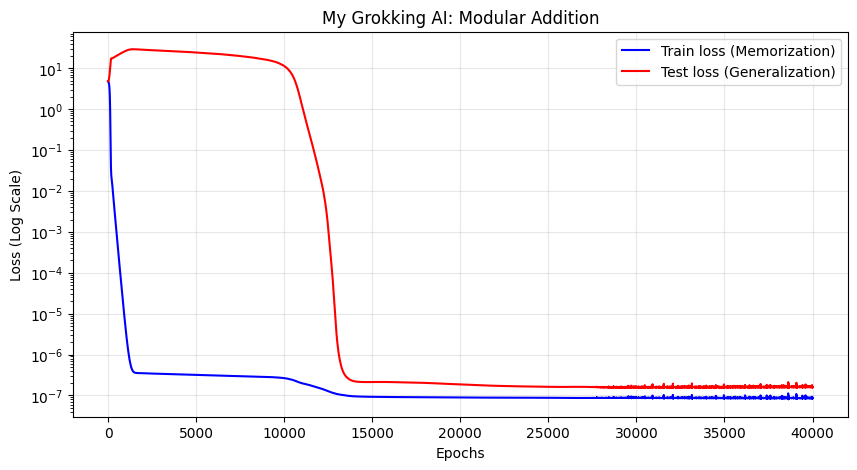

In [ ]:
import torch
import matplotlib.pyplot as plt

# Load your data
data = torch.load('/content/drive/MyDrive/Grokking/full_run_data.pth', map_location='cpu')

# Plot the Grokking curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(data['train_losses'], label='Train loss (Memorization)', color='blue')
ax.semilogy(data['test_losses'], label='Test loss (Generalization)', color='red')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (Log Scale)')
ax.set_title('My Grokking AI: Modular Addition')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()
